# 3. Harmonizing Spatial & Temporal Coordinates

Why Harmonization Matters 

Geospatial datasets often come from  different sources, resolutions, and formats. So, before you can train your AI models, you must harmonize their spatial and temporal properties to ensure compatibility. In this section, we'll transform datasets to share: 

- Identical time resolution
- Same spatial grid
- Consistent coordinate system

## 3.1 Inspecting selected data

### Import libraries

In [1]:
import os                    # Provides functions for interacting with the operating system (file paths, environment variables)
import glob                  # Used for pathname pattern matching to find files matching a specified pattern
from pathlib import Path     # Object-oriented interface for filesystem paths (more modern alternative to os.path)

# Geospatial and climate data libraries
import cfgrib                # Library specifically designed for reading GRIB files (common format for meteorological data)
import cftime                # Provides datetime-like objects for working with calendar systems (especially important for climate data)
import xarray as xr          # Powerful library for working with labeled multi-dimensional arrays (essential for geospatial data handling)

# Zarr and numerical libraries for dataset preparation
import zarr                  # Library for chunked, compressed array storage format suitable for large datasets
import numpy as np           # Fundamental package for scientific computing with support for arrays and mathematical operations

# Date and time handling for temporal data processing
from datetime import datetime # Provides classes for manipulating dates and times

# Spatial resampling library for geospatial data alignment
from pyresample import geometry, kd_tree  # Library for spatial resampling and geolocation of remote sensing data

### Define data paths

In [2]:
# The demo data lives in <repo root>/data/module-00 (see README, "Demo Data")
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_DIR = root / "data" / "module-00"

ERA5_dir = DATA_DIR / "ERA5"
CERRA_dir = DATA_DIR / "CERRA"

# Derived files created by this notebook go to <repo root>/data/derived/module-00
DERIVED_DIR = root / "data" / "derived" / "module-00"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)


### Inspect data structure
#### ERA5

In [3]:
# Collect and examine all GRIB files in the ERA5 directory
# This loop iterates through all GRIB files in the specified ERA5 data directory

era5_files = glob.glob(os.path.join(ERA5_dir, "*.grib"))  # Find all files with .grib extension in ERA5 directory
for file in era5_files:                                   # Iterate through each found GRIB file
    ds = xr.open_dataset(file)                            # Open each GRIB file as an xarray dataset
    print(ds)                                             # Display dataset information
    print("\n")                                          

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    sst         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...




Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-2m_temperature.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 63, step: 12, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 504B 2019-12-31T18:00:00 ... 2020-01-31...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    tp          (time, step, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1..

#### CERRA

In [4]:
# Collect and examine all GRIB files in the CERRA directory
# This loop iterates through all GRIB files in the specified CERRA data directory

cerra_files = glob.glob(os.path.join(CERRA_dir, "*.grib"))  # Find all files with .grib extension in CERRA directory
for file in cerra_files:                                   # Iterate through each found GRIB file
    ds = xr.open_dataset(file)                             # Open each GRIB file as an xarray dataset
    print(ds)   

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-10m_wind_direction.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-10m_wind_speed.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 248, y: 1069, x: 1069)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21...
    valid_time         (time) datetime64[ns] 2kB ...
    latitude           (y, x) float64 9MB ...
    longitude          (y, x) float64 9MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    wdir10             (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-2m_relative_humidity.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 248, y: 1069, x: 1069)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21...
    valid_time         (time) datetime64[ns] 2kB ...
    latitude           (y, x) float64 9MB ...
    longitude          (y, x) float64 9MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    si10               (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-orography.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 248, y: 1069, x: 1069)
Coordinates:
  * time               (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21...
    valid_time         (time) datetime64[ns] 2kB ...
    latitude           (y, x) float64 9MB ...
    longitude          (y, x) float64 9MB ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    r2                 (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...
<xarray.Dataset> Size: 1GB
Dimensions:     (time: 248, y: 1069, x: 1069)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21:00:00
    valid_time  (time)

#### Summary:
| Feature | ERA5 | CERRA |
|---------|------|-------|
| **Time resolution** | Hourly (744 steps) | 3-hourly (248 steps) |
| **Grid type** | Regular latitude/longitude (`regular_ll`) | Rotated grid (`lambert`) |
| **Coordinates** | 1D latitude/longitude | 2D (y,x) grids |
| **Data variables** | `sst`, `tp`, `t2m` | `r2`, `si10`, `wdir10` |

### Spotting differences

#### Temporal

##### Instant vs Accumulative

In [5]:
# Load and examine different climate variables from ERA5 dataset
# This section demonstrates how to access and inspect different meteorological parameters from the same data source

print("#### Sea surface temperature #### \n")
ds1 = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-sea_surface_temperature.grib")
print(ds1)  # Display complete dataset information for sea surface temperature
print("\n")

print("#### Total precipitation #### \n")
ds2 = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-total_precipitation.grib")
print(ds2)  # Display complete dataset information for total precipitation
print("\n")

print("#### Sea surface temperature #### \n")
print(ds1.sst.attrs['GRIB_stepType'])  # Display the GRIB step type attribute for sea surface temperature
print("\n")

print("#### Total precipitation #### \n")
print(ds2.tp.attrs['GRIB_stepType'])   # Display the GRIB step type attribute for total precipitation
print("\n")

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file


#### Sea surface temperature #### 



Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    sst         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


#### Total precipitation #### 

<xarray.Dataset> Size: 3

##### Summary:
- instant data (e.g., temperature) is available at specific moments
- accum data (e.g., precipitation) shows cumulative values over time
- Critical implication: Precipitation needs special handling before comparison

##### Hourly vs 3-hourly

In [6]:
# Compare temporal characteristics of different climate datasets from different sources
# This section demonstrates how to examine and compare time dimensions across heterogeneous datasets

print("#### Sea surface temperature #### \n")
ds1 = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-sea_surface_temperature.grib")
print(ds1)  # Display complete dataset information for sea surface temperature from ERA5
print("\n")

print("#### Total precipitation #### \n")
ds2 = xr.open_dataset(CERRA_dir / "CERRA-AIFTraining-M0-2m_relative_humidity.grib")
print(ds2)  # Display complete dataset information for relative humidity from CERRA
print("\n")

print("#### Sea surface temperature #### \n")
print(ds1.time.values[0:3])  # Display first 3 time values for sea surface temperature
print("\n")
print(f'Total timesteps: {len(ds1.time.values)}')  # Show total number of time steps in ERA5 dataset
print("\n")

print("#### Total precipitation #### \n")
print(ds2.time.values[0:3])  # Display first 3 time values for relative humidity
print("\n")
print(f'Total timesteps: {len(ds2.time.values)}')  # Show total number of time steps in CERRA dataset
print("\n")

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file


#### Sea surface temperature #### 



Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-2m_relative_humidity.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    sst         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


#### Total precipitation #### 

<xarray.Dataset> Size: 1

##### Summary:
- ERA5: 744 hourly timestamps
- CERRA: 248 three-hourly timestamps
- Critical implication: Time steps need harmonization before comparison

#### Spatial

In [7]:
# Compare coordinate systems and grid types between different climate datasets
# This section demonstrates how to examine spatial coordinate structures and grid characteristics across heterogeneous data sources

print("#### Sea surface temperature #### \n")
ds1 = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-sea_surface_temperature.grib")
print(ds1)  # Display complete dataset information for sea surface temperature from ERA5
print("\n")

print("#### Total precipitation #### \n")
ds2 = xr.open_dataset(CERRA_dir / "CERRA-AIFTraining-M0-2m_relative_humidity.grib")
print(ds2)  # Display complete dataset information for relative humidity from CERRA
print("\n")

print("#### ERA5 coordinates #### \n")
print(ds1.coords)  # Display all coordinate variables for ERA5 dataset 
print("\n")

print("#### CERRA coordinates #### \n")
print(ds2.coords)  # Display all coordinate variables for CERRA dataset 
print("\n")

print("#### ERA5 coordinates #### \n")
print(ds1.sst.attrs['GRIB_gridType'])  # Display the GRIB grid type attribute for ERA5 sea surface temperature
print("\n")

print("#### CERRA coordinates #### \n")
print(ds2.r2.attrs['GRIB_gridType'])   # Display the GRIB grid type attribute for CERRA relative humidity
print("\n")

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file


#### Sea surface temperature #### 



Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-2m_relative_humidity.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    sst         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


#### Total precipitation #### 

<xarray.Dataset> Size: 1

##### Summary:
| Feature | ERA5 | CERRA |
|---------|------|-------|
| **Grid type** | `regular_ll` (standard longitude/latitude) | `lambert` (rotated grid) |
| **Coordinates** | 1D latitude/longitude | 2D (y,x) grid |

**Summary of temporal and spatial differences:**
| Aspect | ERA5 | CERRA |
|--------|------|-------|
| **Temporal resolution** | Hourly (744 timesteps) | Three-hourly (248 timesteps) |
| **Data type** | Mostly `instant` | Mixed `instant`/`accum` |
| **Grid type** | `regular_ll` | `lambert` (rotated) |
| **Coordinate structure** | 1D latitude/longitude | 2D (y,x) grids |
| **Data volume** | ~3GB per variable | ~1GB per variable |

**Next Steps:**

- Temporal harmonization: Convert to consistent time resolutions
- Spatial harmonization: Align grids through regridding
- Data merging: Combine processed data into unified dataset

## 3.2 Harmonizing data

### Temporal

#### Converting instantaneous data on mean daily data

In [8]:
# Compare temporal resolution and time dimension characteristics between original and daily-averaged datasets
# This section demonstrates the transformation process from high-frequency to daily-resolution data

print("#### Original dataset #### \n")
print(ds)  # Display the complete original dataset with high temporal resolution
print("\n")

print("#### Daily dataset #### \n")
ds_daily = ds.resample(time="1D").mean()  # Resample original data to daily mean values
print(ds_daily)  # Display the daily-averaged dataset
print("\n")

print("#### Original dataset #### \n")
print(ds.time.values[0:5])  # Display first 5 time values from original dataset
print("\n")
print(f'Total timesteps: {len(ds.time.values)}')  # Show total number of high-frequency time steps
print("\n")

print("#### Daily dataset #### \n")
print(ds_daily.time.values[0:5])  # Display first 5 time values from daily-averaged dataset
print("\n")
print(f'Total timesteps: {len(ds_daily.time.values)}')  # Show total number of daily time steps
print("\n")

#### Original dataset #### 

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 248, y: 1069, x: 1069)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2020-01-01 ... 2020-01-31T21:00:00
    valid_time  (time) datetime64[ns] 2kB ...
    latitude    (y, x) float64 9MB ...
    longitude   (y, x) float64 9MB ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    orog        (time, y, x) float32 1GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-10-02T22:36 GRIB to CDM+CF via cfgrib-0.9.1...


#### Daily dataset #### 

<xarray.Dataset> Size: 160MB
Dimensions:    (time: 31, y: 1069, x: 1069)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    latitude   (

#### Converting accumulative data on mean daily data

In [9]:
ds = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-total_precipitation.grib")

# 1. Compute precipitation increments between forecast steps
#    ECMWF 'tp' is cumulative from the start of the forecast.
#    diff("step") converts cumulative precipitation → precipitation per step.
#    clip(min=0) removes negative values caused by forecast resets.

tp_step = ds["tp"].diff("step").clip(min=0)

# 2. Align the valid_time values with the increments
#    After diff, the first step disappears, so we shift valid_time by one step.
vt = ds["valid_time"].isel(step=slice(1, None))

# 3. Assign valid_time as a coordinate for each increment
#    This allows grouping and resampling using the real timestamps.
tp_step = tp_step.assign_coords(valid_time=vt)

# 4. Group increments by calendar day and sum them
#    This produces daily total precipitation (12h increments → daily totals).
tp_daily = tp_step.groupby("valid_time.date").sum()

# 5. Convert DataArray → Dataset
#    After the groupby operation, tp_daily is a DataArray with dimension "date".
#    Converting it to a Dataset allows adding more variables later if needed.
ds_daily = tp_daily.to_dataset(name="tp")

# Convert the "date" dimension (Python datetime.date objects)
# into proper NumPy datetime64[ns] timestamps.
# This is required because datetime.date cannot be compared with strings
# and cannot be used reliably as a time coordinate.
ds_daily = ds_daily.assign_coords(
    date=ds_daily["date"].astype("datetime64[ns]")
)

# 6. Rename the dimension "date" → "time"
#    Now that "date" is a valid datetime64 coordinate, we can safely rename it.
ds_daily = ds_daily.rename({"date": "time"})

# 7. Select only the desired time range
#    This removes days from the previous and next month that appear due to forecast overlap.
ds_daily = ds_daily.sel(time=slice("2020-01-01", "2020-01-31"))

print(ds_daily)

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 129MB
Dimensions:    (latitude: 721, longitude: 1440, time: 31)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    number     int64 8B ...
    surface    float64 8B ...
Data variables:
    tp         (latitude, longitude, time) float32 129MB 1.049e-05 ... 9.537e-07


#### Defining functions for preavious processing

In [10]:
# Define functions for processing different types of climate data variables
# These functions handle the specific processing requirements for instantaneous and accumulated variables

def process_inst_daily(ds,var_name):
    # Process instantaneous variables (like temperature) by taking daily averages
    ds_daily = ds.resample(time="1D").mean()  # Resample to daily mean values
    ds_daily = ds_daily.to_dataset(name=var_name)  # Convert back to dataset with specified variable name
    return ds_daily

def process_acc_daily(ds,var_name):
    # Process accumulated variables (like precipitation) by handling time steps properly
    ds_step = ds.diff("step").clip(min=0)  # Calculate differences between time steps and ensure non-negative values
    vt = ds["valid_time"].isel(step=slice(1, None))  # Get valid times for subsequent steps
    ds_step = ds_step.assign_coords(valid_time=vt)  # Assign updated valid times to the step data
    ds_daily = ds_step.groupby("valid_time.date").sum()  # Group by date and sum accumulated values
    ds_daily = ds_daily.to_dataset(name=var_name)  # Convert back to dataset with specified variable name
    ds_daily = ds_daily.assign_coords(
        date=ds_daily["date"].astype("datetime64[ns]")  # Ensure proper datetime format for date coordinates
    )
    ds_daily = ds_daily.rename({"date": "time"})  # Rename date dimension to time for consistency
    ds_daily = ds_daily.sel(time=slice("2020-01-01", "2020-01-31"))  # Select specific time period (January 2020)
    return(ds_daily)

#### Applying functions

In [11]:
# Process all GRIB files in the ERA5 directory with appropriate variable-specific handling
# This loop systematically processes each climate variable from all ERA5 GRIB files using type-specific functions

era5_files = glob.glob(os.path.join(ERA5_dir, "*.grib"))  # Find all GRIB files in ERA5 directory
for file in era5_files:                                   # Iterate through each GRIB file
    ds = xr.open_dataset(file)                            # Open the current GRIB file as an xarray dataset
    for var in ds.data_vars:                              # Iterate through each variable in the dataset
        if 'GRIB_stepType' in ds[var].attrs:              # Check if the variable has GRIB step type metadata
            if ds[var].attrs['GRIB_stepType'] == 'instant':  # If it's an instantaneous variable
                ds_daily = process_inst_daily(ds[var], var)   # Process using instantaneous function
            elif ds[var].attrs['GRIB_stepType'] == 'accum': # If it's an accumulated variable
                ds_daily = process_acc_daily(ds[var], var)    # Process using accumulated function
            print(ds_daily) 

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 129MB
Dimensions:    (latitude: 721, longitude: 1440, time: 31)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    sst        (time, latitude, longitude) float32 129MB 271.5 271.5 ... nan nan


Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-2m_temperature.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 129MB
Dimensions:    (latitude: 721, longitude: 1440, time: 31)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    number     int64 8B ...
    surface    float64 8B ...
Data variables:
    tp         (latitude, longitude, time) float32 129MB 1.049e-05 ... 9.537e-07
<xarray.Dataset> Size: 129MB
Dimensions:    (latitude: 721, longitude: 1440, time: 31)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    t2m        (time, latitude, longitude) float32 129MB 245.

#### Merging datasets

In [12]:
# Initialize an empty dataset that will accumulate all variables
# This allows merging each processed variable as soon as it is created.
merged_ds_temp = xr.Dataset()

for file in era5_files:
    ds = xr.open_dataset(file)

    for var in ds.data_vars:

        # Check if the variable has GRIB metadata
        if "GRIB_stepType" in ds[var].attrs:

            # Instantaneous variable → daily mean/max/min (depending on your function)
            if ds[var].attrs["GRIB_stepType"] == "instant":
                ds_daily = process_inst_daily(ds[var], var)

            # Accumulated variable → convert to daily totals
            elif ds[var].attrs["GRIB_stepType"] == "accum":
                ds_daily = process_acc_daily(ds[var], var)

            # Merge iteratively
            # combine_by_coords ensures safe alignment on time/lat/lon
            merged_ds_temp = xr.combine_by_coords([merged_ds_temp, ds_daily], compat="override")

print(merged_ds_temp)

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-total_precipitation.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-2m_temperature.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 386MB
Dimensions:    (latitude: 721, longitude: 1440, time: 31)
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    sst        (time, latitude, longitude) float32 129MB 271.5 271.5 ... nan nan
    tp         (latitude, longitude, time) float32 129MB 1.049e-05 ... 9.537e-07
    t2m        (time, latitude, longitude) float32 129MB 245.9 245.9 ... 236.4


### Spatial

In [13]:
# Load reference datasets from different climate data sources for comparison and harmonization
# This section demonstrates how to access and examine datasets from different providers (ERA5 vs CERRA)

print("#### ERA5 #### \n")
ds_ref = xr.open_dataset(ERA5_dir / "ERA5-AIFTraining-M0-sea_surface_temperature.grib")
print(ds_ref)  # Display complete dataset information for sea surface temperature from ERA5
print("\n")

print("#### CERRA #### \n")
ds_curv = xr.open_dataset(CERRA_dir / "CERRA-AIFTraining-M0-2m_relative_humidity.grib")
print(ds_curv)  # Display complete dataset information for relative humidity from CERRA
print("\n")

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/ERA5/ERA5-AIFTraining-M0-sea_surface_temperature.grib.5b7b6.idx' incompatible with GRIB file


#### ERA5 #### 



Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-2m_relative_humidity.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 744, latitude: 721, longitude: 1440)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    sst         (time, latitude, longitude) float32 3GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-10-02T22:39 GRIB to CDM+CF via cfgrib-0.9.1...


#### CERRA #### 

<xarray.Dataset> Size: 1GB
Dimensions:

#### Defining reference grid

In [14]:
# 1. Extract the reference grid from an existing dataset
#    This dataset defines the spatial domain and resolution we want to use.
lat_ref = ds_ref.latitude
lon_ref = ds_ref.longitude

# 2. Create an empty reference grid dataset
#    This grid will be used as the target for interpolation.
ds_ref = xr.Dataset(
    coords={
        "latitude": lat_ref,
        "longitude": lon_ref
    }
)

#### Temporal harmonization and longitud normalization

In [15]:
# Prepare and align longitude coordinates between reference and current datasets
# This section demonstrates the necessary preprocessing steps for spatial coordinate alignment

ds_curv = ds_curv.resample(time="1D").mean()  # Resample CERRA dataset to daily resolution for consistency
lon_curv = ((ds_curv.longitude.values + 180) % 360) - 180  # Normalize longitude coordinates for CERRA dataset
lon_ref = ((ds_ref.longitude.values + 180) % 360) - 180   # Normalize longitude coordinates for ERA5 dataset

#### Defining source grid

In [16]:
# Define spatial geometries for resampling operations between different climate datasets
# This section demonstrates how to create coordinate definitions for spatial regridding

source = geometry.SwathDefinition(
    lons=lon_curv,           # Longitude coordinates from CERRA dataset (normalized)
    lats=ds_curv.latitude.values  # Latitude coordinates from CERRA dataset
)

lon2d, lat2d = np.meshgrid(lon_ref, ds_ref.latitude.values)  # Create 2D grid from reference coordinates

target = geometry.GridDefinition(
    lons=lon2d,              # 2D longitude grid from ERA5 dataset
    lats=lat2d)               # 2D latitude grid from ERA5 dataset

#### Interpolation

In [17]:
# Perform spatial resampling of CERRA data to match ERA5 grid coordinates
# This section demonstrates the core spatial interpolation process for dataset harmonization

interp_list = []
for t in range(ds_curv.time.size):  # Iterate through each time step in the CERRA dataset
    data_t = ds_curv["r2"].isel(time=t).values  # Extract temperature values for current time step
    data_interp = kd_tree.resample_nearest(
        source,                    # Source geometry (CERRA coordinates)
        data_t,                    # Data values from CERRA at current time step
        target,                    # Target geometry (ERA5 grid coordinates)
        radius_of_influence=50000,  # Search radius of 50 km for nearest neighbor interpolation
        fill_value=np.nan          # Fill missing values with NaN
    )
    interp_list.append(data_interp)  # Store interpolated data for each time step

#### Interpolated dataset

In [18]:
# Combine interpolated spatially-resampled data into a unified xarray dataset
# This section demonstrates how to assemble the processed data into a proper dataset structure

ds_interp = xr.DataArray(
    np.stack(interp_list),  # Stack all time-step interpolated arrays into a 3D array
    dims=("time", "latitude", "longitude"),  # Define dimensions: time, latitude, longitude
    coords={
        "time": ds_curv.time,     # Use original CERRA time coordinates
        "latitude": ds_ref.latitude,  # Use ERA5 latitude coordinates (target grid)
        "longitude": ds_ref.longitude  # Use ERA5 longitude coordinates (target grid)
    },
    name="r2"  # Name the data variable
).to_dataset()  # Convert DataArray to Dataset format

ds_interp.attrs = ds_curv.attrs.copy()  # Copy attributes from original CERRA dataset
print(ds_interp)  # Display the final interpolated dataset

<xarray.Dataset> Size: 129MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    r2         (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
Attributes:
    GRIB_edition:            2
    GRIB_centre:             eswi
    GRIB_centreDescription:  Norrkoping
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Norrkoping
    history:                 2026-10-02T22:39 GRIB to CDM+CF via cfgrib-0.9.1...


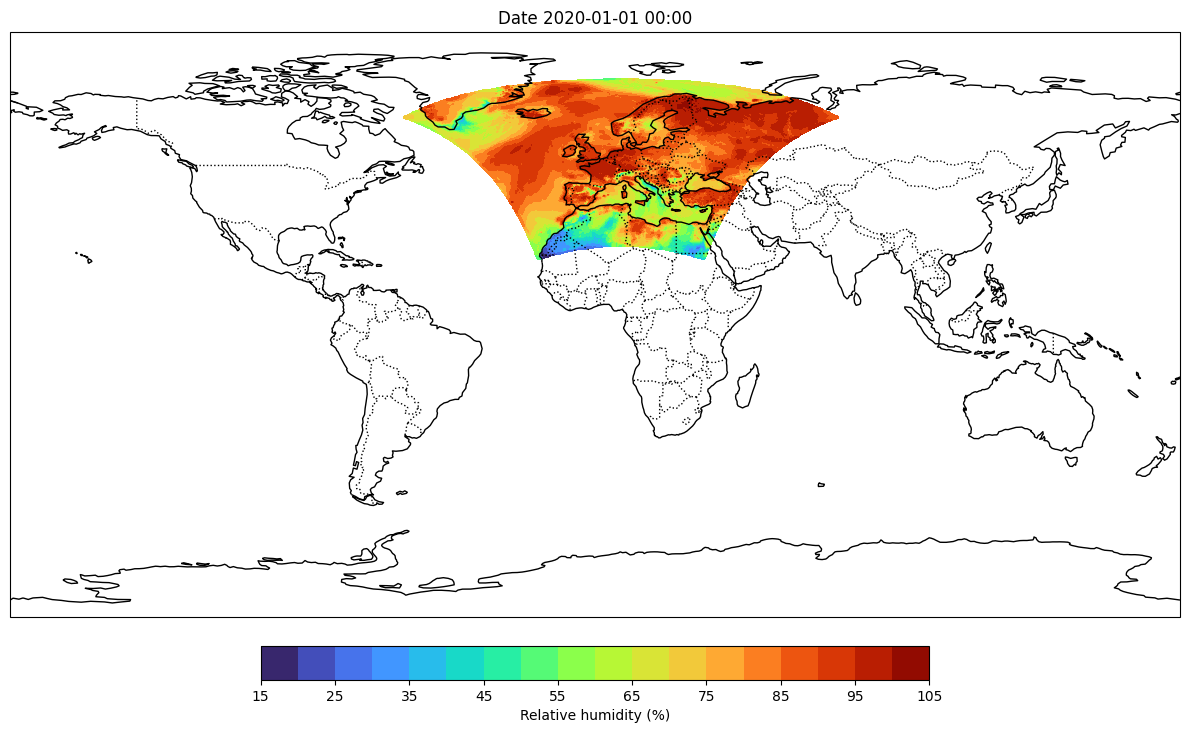

In [19]:
# Visualize the spatial distribution of relative humidity data using cartographic plotting
# This section demonstrates how to create geographic visualizations of climate data

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy

r2_data = ds_interp['r2'].isel(time=0)  # Extract first time step from interpolated dataset
r2_values = r2_data.values             # Get the actual numerical values for plotting

# Create figure with cartographic projection
fig = plt.figure(figsize=(12, 8))      # Set figure size for better visualization
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())  # Create subplot with PlateCarree projection

# Create the contour plot
contourf = ax.contourf(r2_data.longitude, r2_data.latitude, r2_values,
                       levels=20, cmap='turbo', transform=ccrs.PlateCarree())  # 20 contour levels with turbo colormap

# Add colorbar correctly
cbar = plt.colorbar(contourf, ax=ax, label='Relative humidity (%)', orientation='horizontal', fraction=0.046, pad=0.04)
# Add geographic features
ax.coastlines()                        # Add coastlines for geographic reference
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')  # Add country borders

# Add title with date information
plt.title(f'Date {ds_interp.time[0].dt.strftime("%Y-%m-%d %H:%M").values}')  # Title with timestamp

# Show the plot
plt.tight_layout()                     # Adjust layout for better appearance
plt.show()                             # Display the visualization

#### Defining interpolation function

In [20]:
# Define a comprehensive function for spatial resampling between different climate datasets
# This function encapsulates the complete spatial harmonization process for any variable

def interp(ds_ref, ds_curv, var_name):
    # Normalize longitude coordinates to ensure compatibility between datasets
    lon_curv = ((ds_curv.longitude.values + 180) % 360) - 180  # Convert CERRA longitudes to -180 to 180 range
    lon_ref = ((ds_ref.longitude.values + 180) % 360) - 180   # Convert ERA5 longitudes to -180 to 180 range
    
    # Define source geometry (CERRA dataset coordinates)
    source = geometry.SwathDefinition(
        lons=lon_curv,
        lats=ds_curv.latitude.values
    )
    
    # Create target grid definition (ERA5 dataset coordinates)
    lon2d, lat2d = np.meshgrid(lon_ref, ds_ref.latitude.values)
    target = geometry.GridDefinition(
        lons=lon2d,
        lats=lat2d
    )
    
    # Perform spatial resampling for each time step
    interp_list = []
    for t in range(ds_curv.time.size):  # Iterate through all time steps in the current dataset
        data_t = ds_curv[var_name].isel(time=t).values  # Extract data for current time step
        data_interp = kd_tree.resample_nearest(
            source,                    # Source geometry (CERRA coordinates)
            data_t,                    # Data values from CERRA at current time step
            target,                    # Target geometry (ERA5 grid coordinates)
            radius_of_influence=50000,  # Search radius of 50 km for nearest neighbor interpolation
            fill_value=np.nan          # Fill missing values with NaN
        )
        interp_list.append(data_interp)  # Store interpolated data
    
    # Assemble the final interpolated dataset
    ds_interp = xr.DataArray(
        np.stack(interp_list),     # Stack all time-step interpolated arrays
        dims=("time", "latitude", "longitude"),  # Define dimensions
        coords={
            "time": ds_curv.time,     # Use original CERRA time coordinates
            "latitude": ds_ref.latitude,  # Use ERA5 latitude coordinates (target grid)
            "longitude": ds_ref.longitude  # Use ERA5 longitude coordinates (target grid)
        },
        name=var_name              # Name the data variable
    ).to_dataset()                 # Convert to Dataset format
    
    return ds_interp               # Return the fully processed and harmonized dataset

#### Merge of interpolated datasets

In [21]:
# Process all CERRA GRIB files and merge variables into a unified dataset
# This section demonstrates how to systematically process multiple files and variables while maintaining data consistency

# Initialize an empty dataset that will accumulate all variables
# This allows merging each processed variable as soon as it is created, building up the final dataset incrementally
merged_ds_interp = xr.Dataset()

cerra_files = glob.glob(os.path.join(CERRA_dir, "*.grib"))  # Find all GRIB files in CERRA directory
for file in cerra_files:                                   # Iterate through each CERRA GRIB file
    ds = xr.open_dataset(file)                             # Open the current CERRA file as an xarray dataset
    for var in ds.data_vars:                               # Iterate through each variable in the dataset
        # Check if the variable has GRIB metadata (indicating it can be processed)
        if "GRIB_stepType" in ds[var].attrs:              # Verify variable has required metadata
            ds_curv = ds.resample(time="1D").mean()       # Resample to daily resolution for consistency
            ds_interp = interp(ds_ref, ds_curv, var)      # Apply spatial interpolation using our comprehensive function
            merged_ds_interp = xr.combine_by_coords([merged_ds_interp, ds_interp], compat="override")
            # Combine the interpolated dataset with the accumulated dataset using coordinate-based merging
            # The compat="override" parameter allows overwriting existing coordinates when needed

print(merged_ds_interp)  # Display the final merged dataset with all processed variables

Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-10m_wind_direction.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-10m_wind_speed.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-2m_relative_humidity.grib.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/home/fdainell/Documents/AIF-Training-ML-for-ESM-and-Anemoi/data/module-00/CERRA/CERRA-AIFTraining-M0-orography.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 515MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    si10       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    r2         (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    orog       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan


### Merging all data

In [22]:
# Combine spatially harmonized datasets and ensure consistent variable dimensions
# This section demonstrates how to merge different processed datasets and standardize their structure

merged_ds = xr.combine_by_coords([merged_ds_interp, merged_ds_temp], compat="override")
# Merge the interpolated CERRA dataset with the temperature dataset using coordinate-based merging
# The compat="override" parameter allows overwriting existing coordinates when needed

for var in merged_ds.data_vars:  # Iterate through each variable in the combined dataset
    dims = merged_ds[var].dims  # Get the current dimension order of the variable
    if dims != ("time", "latitude", "longitude"):  # Check if dimensions are not in the desired order
        merged_ds[var] = merged_ds[var].transpose("time", "latitude", "longitude")

print(merged_ds)  # Display the final unified dataset with standardized variable structures

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    si10       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    r2         (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    orog       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    sst        (time, latitude, longitude) float32 129MB 271.5 271.5 ... nan nan
    tp         (time, latitude, longitude) float32 129MB 1.049e-05 ... 9.537e-07
    t2m        (time, latitude, longitude) float32 129MB 245.9 245

# 4. Preparing & Writing ARCO-Ready Zarr Datasets
## 4.1 Metadata consolidation
### The role of CF metadata
CF (Climate and Forecast) conventions are the international standard for geospatial and climate data. Without CF compliance, your data is:
- Uninterpretable by most climate software
- Unusable for machine learning models
- Rejected by platforms like ARCO

### Defining specific metadata

In [23]:
# Define comprehensive metadata configuration for all climate variables
# This dictionary provides standardized metadata attributes for consistent dataset documentation

metadata_config = {
    "t2m": {
        "long_name": "2-meter temperature",
        "units": "K",
        "standard_name": "air_temperature",
        "valid_range": [100, 350],  # Reasonable temperature range
        "missing_value": np.nan,
        "description": "Temperature at 2 meters above ground level"
    },
    "tp": {
        "long_name": "Total precipitation",
        "units": "m",
        "standard_name": "precipitation_flux",
        "valid_range": [0, 0.1],
        "missing_value": np.nan,
        "description": "Total accumulated precipitation"
    },
    "r2": {
        "long_name": "Relative humidity",
        "units": "%",
        "standard_name": "relative_humidity",
        "valid_range": [0, 100],
        "missing_value": np.nan,
        "description": "Relative humidity at 2 meters"
    },
    "si10": {
        "long_name": "10-meter wind speed",
        "units": "m/s",
        "standard_name": "wind_speed",
        "valid_range": [0, 100],
        "missing_value": np.nan,
        "description": "Wind speed at 10 meters above ground level"
    },
    "wdir10": {
        "long_name": "10-meter wind direction",
        "units": "degrees",
        "standard_name": "wind_from_direction",
        "valid_range": [0, 360],
        "missing_value": np.nan,
        "description": "Wind direction at 10 meters"
    },
    "orog": {
        "long_name": "Orography (elevation)",
        "units": "m",
        "standard_name": "height",
        "valid_range": [0, 10000],
        "missing_value": np.nan,
        "description": "Surface elevation above sea level"
    },
    "sst": {
        "long_name": "Sea surface temperature",
        "units": "K",
        "standard_name": "sea_surface_temperature",
        "valid_range": [250, 300],
        "missing_value": np.nan,
        "description": "Temperature at the ocean surface"
    }
}

Attributes description:
| Attribute | What It Does | Why It's Critical |
|-----------|--------------|------------------|
| `long_name` | Human-readable name | Ensures clarity for users |
| `units` | Specifies measurement units | Prevents misinterpretation of values |
| `standard_name` | CF-compliant identifier | Required by ARCO for data validation |
| `valid_range` | Defines acceptable data values | Enables quality control |
| `description` | Explains what the variable represents | Critical for scientific interpretation |

### Defining and applying global metadata

In [24]:
# Add comprehensive dataset-level metadata attributes
# This section provides global dataset information that describes the entire climate dataset

merged_ds.attrs = {
    "title": "Daily climate variables for January 2020",
    "source": "ERA5 and CERRA datasets",
    "institution": "European Centre for Medium-Range Weather Forecasts",
    "description": "Harmonized climate dataset for machine learning applications",
    "processing_history": "1. Temporal harmonization (daily means), 2. Spatial regridding to ERA5 grid, 3. Zarr compression (zstd)",
    "time_coverage_start": "2020-01-01",
    "time_coverage_end": "2020-01-31",
    "geographic_coverage": {
        "north": 90.0,
        "south": -90.0,
        "east": 359.8,
        "west": 0.0
    }
}

# 1. Complete dataset documentation including title and description
# 2. Source information identifying the original data providers (ERA5 and CERRA)
# 3. Processing history showing the steps taken to harmonize the data
# 4. Temporal coverage specifying the date range (January 2020)
# 5. Geographic boundaries defining the spatial extent of the dataset
# 6. Standardized metadata structure following CF conventions

Global attributes:
- title/description: Provide complete context
- source/institution: Ensures data provenance
- processing_history: Documents transformation steps
- time_coverage/geographic_coverage: Essential for temporal and spatial analysis

### Applying specific metadata

In [25]:
# Apply standardized metadata attributes to all variables in the merged dataset
# This ensures each climate variable has proper documentation and attributes

for var in merged_ds.data_vars:  # Iterate through each variable in the merged dataset
    if var in metadata_config:   # Check if the variable has defined metadata configuration
        merged_ds[var].attrs = metadata_config[var]  # Assign the standardized metadata to the variable

print("#### ARCO dataset #### \n")
print(merged_ds)  # Display the complete merged dataset with all variables and their attributes
print("\n")

print("#### Relative humidity #### \n")
print(merged_ds.r2)  # Display detailed information about the relative humidity variable specifically

#### ARCO dataset #### 

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    si10       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    r2         (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    orog       (time, latitude, longitude) float32 129MB nan nan nan ... nan nan
    sst        (time, latitude, longitude) float32 129MB 271.5 271.5 ... nan nan
    tp         (time, latitude, longitude) float32 129MB 1.049e-05 ... 9.537e-07
    t2m        (time, latitude, longitude

## Zarr formating

Zarr is the  industry standard for efficient large-scale data storage, especially when working with: 

- Climate data (which is typically massive) 
- Multi-dimensional arrays (like your 721×1440×31 dataset) 
- Parallel processing (needed for machine learning applications)

Zarr is the preferred format for large-scale geospatial data because:

- Efficient storage (60-80% smaller than netCDF)
- Parallel access (critical for machine learning)
- Version control (easy data updates)
- Cloud compatibility 

## Defining chunks

### What Are Chunks? 

Chunks are  small pieces of your dataset that get stored and processed separately. Choosing the right chunk size affects: 
- Reading speed
- Memory usage
- Parallel processing capabilities
  
Because:
- Each chunk is a subarray of your data
- Chunks are independent and can be processed in parallel
- Chunk size affects memory usage and processing speed

In [26]:
print(merged_ds.chunk())

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 129MB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
    r2         (time, latitude, longitude) float32 129MB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
    orog       (time, latitude, longitude) float32 129MB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
    sst        (time, latitude, longitude) float32 129MB dask.array<chunksize=(31, 721, 1440), meta=np.n

In [27]:
# Configure chunking strategy for obtaining time slices

merged_ds = merged_ds.chunk({"time": 1})  # Set time dimension chunk size to 1 for fine-grained access
print(merged_ds.chunk())  # Display the chunk configuration of the dataset

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    r2         (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    orog       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    sst        (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarra

In [28]:
merged_ds = merged_ds.chunk({"time": 1, "latitude": 250, "longitude": 250})  
# Set chunk sizes: time=1 (fine-grained temporal access), latitude=250, longitude=250 (spatial blocks)
print(merged_ds.chunk())  # Display the complete chunk configuration of the dataset

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    wdir10     (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    r2         (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    orog       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    sst        (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
  

### Memory vs Speed Tradeoff:
- Smaller chunks: Better parallelism (faster processing) but higher memory overhead
- Larger chunks: Less memory but slower parallel processing

## Compression and Encoding

Encoding defines how data is compressed before storage. For climate data:
- Requires high compression (smaller storage)
- Needs efficient decompression (fast analysis)
- Must preserve precision (critical for scientific data)

In [29]:
# Configure compression encoding for Zarr dataset storage optimization

import numcodecs
compressor = numcodecs.Blosc(cname="zstd", clevel=5, shuffle=2)
# Create Blosc compressor with Zstandard algorithm (zstd), compression level 5, and shuffle filtering
encoding = {
    var: {
        "compressor": compressor,
        "dtype": "float32"
    }
    for var in merged_ds.data_vars
}
print(encoding)  # Display the complete encoding configuration for all variables

# 1. Use of Blosc compressor with Zstandard (zstd) algorithm for efficient compression
# 2. Compression level 5 for balanced compression ratio and processing speed
# 3. Shuffle filtering (shuffle=2) to improve compression efficiency of climate data
# 4. Uniform encoding strategy applied to all variables in the dataset
# 5. Data type specification (float32) for optimal storage efficiency

{'wdir10': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 'si10': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 'r2': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 'orog': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 'sst': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 'tp': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}, 't2m': {'compressor': Blosc(cname='zstd', clevel=5, shuffle=BITSHUFFLE, blocksize=0), 'dtype': 'float32'}}


### What each parameter does:
| Parameter | Value | Purpose | Why It Matters |
|-----------|-------|---------|----------------|
| `cname` | `zstd` | Compression algorithm | **Zstandard** offers best balance of speed & compression |
| `clevel` | 5 | Compression level | **Level 5** balances speed vs compression ratio |
| `shuffle` | 2 | Data shuffling | **BITSHUFFLE** (shuffling level 2) greatly improves compression |

### How this works:

**1. Zstandard (zstd): Compression algorithm that provides:**
- High compression ratios (2-3x smaller storage)
- Fast compression/decompression
- Better compression than gzip
     
**2. Level 5:**
- 10% better compression than level 3
- Only 50% slower compression than level 3
- Best performance/quality tradeoff
     
**3. Shuffle Level 2 (BITSHUFFLE):**
- Makes data more compressible by rearranging bits
- Crucial for repetitive climate data
- Improves compression by 20-50%

## Saving dataset as zarr

In [30]:
# Save the finalized climate dataset to Zarr format for machine learning applications
# This section demonstrates the complete export process to create a production-ready Zarr dataset

save_path = DERIVED_DIR / "training_dataset.zarr"
merged_ds.to_zarr(save_path, mode="w", encoding=encoding, consolidated=True)
# Save the merged dataset as a Zarr file with:
# - save_path (data/derived/module-00/training_dataset.zarr) as the output location
# - mode="w" for write mode (overwrites if file exists)
# - encoding=encoding for specified compression settings
# - consolidated=True for optimized metadata storage

## Inspecting zarr store

In [31]:
# Load and verify the saved Zarr dataset to confirm successful export
# This section demonstrates how to access and inspect the Zarr dataset after saving

zarr_path = DERIVED_DIR / "training_dataset.zarr"  # Define the path to the Zarr dataset
z = xr.open_zarr(zarr_path)         # Open the Zarr dataset using xarray
print(z)                            # Display information about the loaded dataset

<xarray.Dataset> Size: 901MB
Dimensions:    (time: 31, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B ...
    step       timedelta64[ns] 8B ...
    surface    float64 8B ...
Data variables:
    orog       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    r2         (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    si10       (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    sst        (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
    t2m        (time, latitude, longitude) float32 129MB dask.array<chunksize=(1, 250, 250), meta=np.ndarray>
  